In [2]:
pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 4.2 MB/s eta 0:00:09
   - -------------------------------------- 1.0/36.5 MB 4.2 MB/s eta 0:00:09
   -- ------------------------------------- 2.1/36.5 MB 3.6 MB/s eta 0:00:10
   -- ------------------------------------- 2.4/36.5 MB 3.5 MB/s eta 0:00:10
   --- ------------------------------------ 2.9/36.5 MB 2.8 MB/s eta 0:00:12
   ---- ----------------------------------- 3.9/36.5 MB 3.3 MB/s eta 0:00:10
   ---- ----------------------------------- 4.2/36.5 MB 2.9 MB/s eta 0:00:12
   ----- ---------------------------------- 4.7/36.5 MB 3.0 MB/s eta 0:00:11
   ------ --------------------------------- 5.8/36.5 MB 3.1 MB/s eta 0:00:10
   ------- -------------------------------- 7.1/36.5 MB 3.4 MB/s eta 0:00:09
   -------- ------------------------------- 8.1/36.5 MB 3.7 MB/s eta 0:00:08
   ---------- ----------------------------- 9.7/36.5 MB 4.0 MB/s eta 0:00:07
   ---


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip show scipy

Name: scipy
Version: 1.17.1
Summary: Fundamental algorithms for scientific computing in Python
Home-page: https://scipy.org/
Author: 
Author-email: 
License: Copyright (c) 2001-2002 Enthought, Inc. 2003, SciPy Developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions
 are met:

 1. Redistributions of source code must retain the above copyright
    notice, this list of conditions and the following disclaimer.

 2. Redistributions in binary form must reproduce the above
    copyright notice, this list of conditions and the following
    disclaimer in the documentation and/or other materials provided
    with the distribution.

 3. Neither the name of the copyright holder nor the names of its
    contributors may be used to endorse or promote products derived
    from this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS A

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.rcParams["figure.figsize"]=(12,6)

In [6]:
nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv",
    encoding="latin1"
)

fund = pd.read_csv(
    "../data/raw/01_fund_master.csv",
    encoding="latin1"
)

print(nav.shape)
print(benchmark.shape)

(46000, 3)
(8050, 3)


In [7]:
nav['date'] = pd.to_datetime(
    nav['date']
)

nav = nav.sort_values(
    ['amfi_code','date']
)

nav['daily_return'] = (
    nav.groupby(
        'amfi_code'
    )['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [8]:
nav.to_csv(
    "../outputs/daily_returns.csv",
    index=False
)

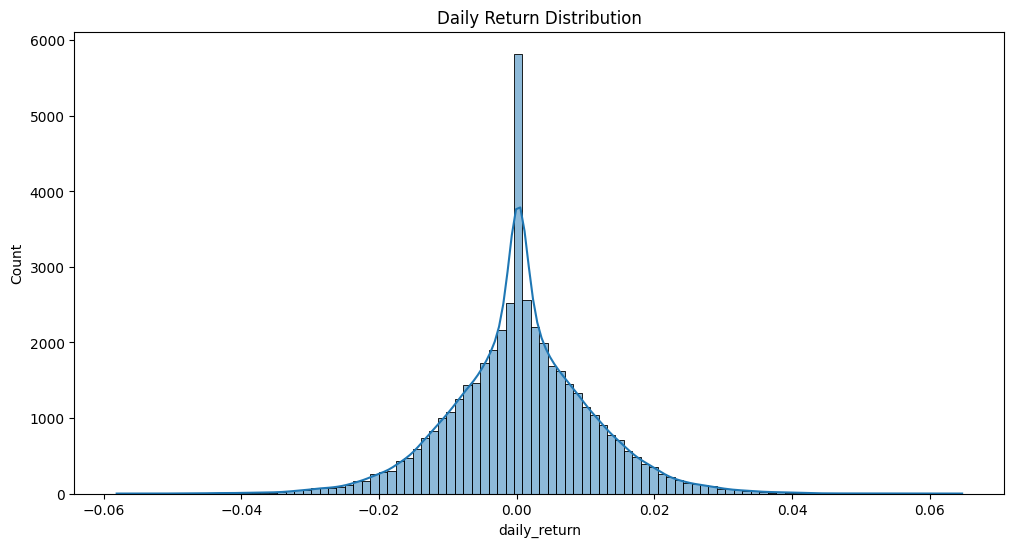

In [9]:
sns.histplot(
    nav['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [10]:
cagr_results = []

for code in nav['amfi_code'].unique():

    df = nav[
        nav['amfi_code']==code
    ]

    start_nav = df.iloc[0]['nav']

    end_nav = df.iloc[-1]['nav']

    years = (
        (df.iloc[-1]['date']
        -
        df.iloc[0]['date']).days
    )/365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
        -
        1
    )

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [11]:
cagr_df.to_csv(
    "../outputs/cagr_table.csv",
    index=False
)

In [12]:
RF = 0.065

In [13]:
sharpe_list = []

for code in nav['amfi_code'].unique():

    r = nav[
        nav['amfi_code']==code
    ]['daily_return'].dropna()

    sharpe = (
        (r.mean()*252 - RF)
        /
        (r.std())
    ) * np.sqrt(252)

    sharpe_list.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,364.969375
30,120843,329.299480
36,148569,311.202366
19,119551,304.483175
25,120505,297.385502


In [14]:
sharpe_df.to_csv(
    "../outputs/sharpe_ratio.csv",
    index=False
)

In [15]:
sortino_list = []

for code in nav['amfi_code'].unique():

    r = nav[
        nav['amfi_code']==code
    ]['daily_return'].dropna()

    downside = r[r < 0]

    sortino = (
        (r.mean()*252 - RF)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_list.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

In [16]:
sortino_df.to_csv(
    "../outputs/sortino_ratio.csv",
    index=False
)

In [17]:
print(benchmark.columns)
print(benchmark.head())

Index(['date', 'index_name', 'close_value'], dtype='str')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [18]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby(
        'index_name'
    )['close_value']
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [19]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
][['date', 'benchmark_return']]

In [20]:
alpha_beta = []

for code in nav['amfi_code'].unique():

    fund_returns = nav[
        nav['amfi_code'] == code
    ][['date','daily_return']]

    merged = pd.merge(
        fund_returns,
        nifty100,
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 20:

        slope, intercept, r, p, stderr = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [21]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

In [22]:
drawdowns = []

for code in nav['amfi_code'].unique():

    df = nav[
        nav['amfi_code'] == code
    ].copy()

    df['running_max'] = (
        df['nav'].cummax()
    )

    df['drawdown'] = (
        df['nav']
        /
        df['running_max']
        -
        1
    )

    max_dd = df['drawdown'].min()

    drawdowns.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [23]:
drawdown_df.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

In [24]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    drawdown_df,
    on='amfi_code'
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown
0,100016,0.026352,-50.782301,0.037476,-0.058268,-0.247344
1,100025,0.044551,-142.907888,0.042818,0.001158,-0.043083
2,100033,0.300997,275.612083,0.271954,0.005104,-0.162172
3,101206,0.235205,258.857759,0.213998,0.021086,-0.112916
4,101207,0.079331,40.990514,0.108971,-0.065289,-0.354469


In [25]:
scorecard['return_rank'] = (
    scorecard['cagr']
    .rank(ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

In [26]:
scorecard['fund_score'] = (

    0.30 *
    scorecard['return_rank']

    +

    0.25 *
    scorecard['sharpe_rank']

    +

    0.20 *
    scorecard['alpha_rank']

    +

    0.25 *
    scorecard['drawdown_rank']

)

scorecard = scorecard.sort_values(
    'fund_score'
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
34,148567,0.309499,364.969375,0.269838,0.023684,-0.112657,5.0,1.0,7.0,8.0,5.15
30,120843,0.308833,329.299480,0.273305,-0.022830,-0.129740,6.0,2.0,5.0,13.0,6.55
36,148569,0.319245,311.202366,0.282704,0.018134,-0.163967,4.0,3.0,4.0,21.0,8.00
25,120505,0.328016,297.385502,0.292636,0.000549,-0.181885,1.0,5.0,3.0,25.0,8.40
2,100033,0.300997,275.612083,0.271954,0.005104,-0.162172,7.0,7.0,6.0,20.0,10.05
19,119551,0.257849,304.483175,0.232010,-0.031751,-0.150124,10.0,4.0,10.0,17.0,10.25
3,101206,0.235205,258.857759,0.213998,0.021086,-0.112916,12.0,9.0,12.0,9.0,10.50
38,149323,0.295581,285.294707,0.265986,-0.002523,-0.172481,8.0,6.0,8.0,22.0,11.00
24,120504,0.232774,258.684120,0.211948,0.016232,-0.125883,13.0,10.0,13.0,12.0,12.00
9,118632,0.240312,272.578113,0.218294,-0.008354,-0.174141,11.0,8.0,11.0,23.0,13.25


In [27]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

In [28]:
top5 = scorecard.head(5)[
    'amfi_code'
].tolist()

top_nav = nav[
    nav['amfi_code'].isin(top5)
]

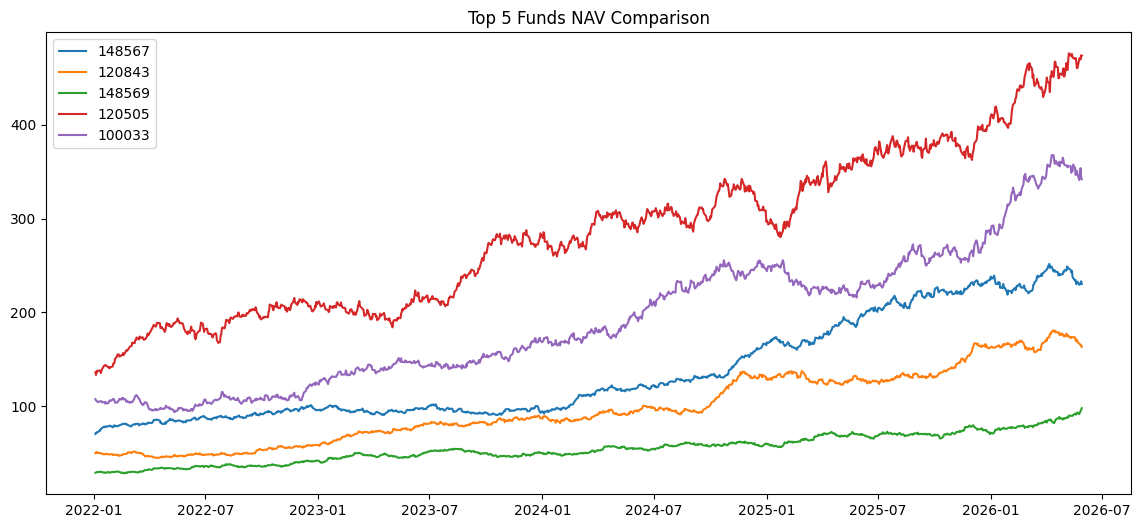

In [29]:
plt.figure(figsize=(14,6))

for code in top5:

    temp = top_nav[
        top_nav['amfi_code']==code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.savefig(
    "../charts/benchmark_comparison.png"
)

plt.show()

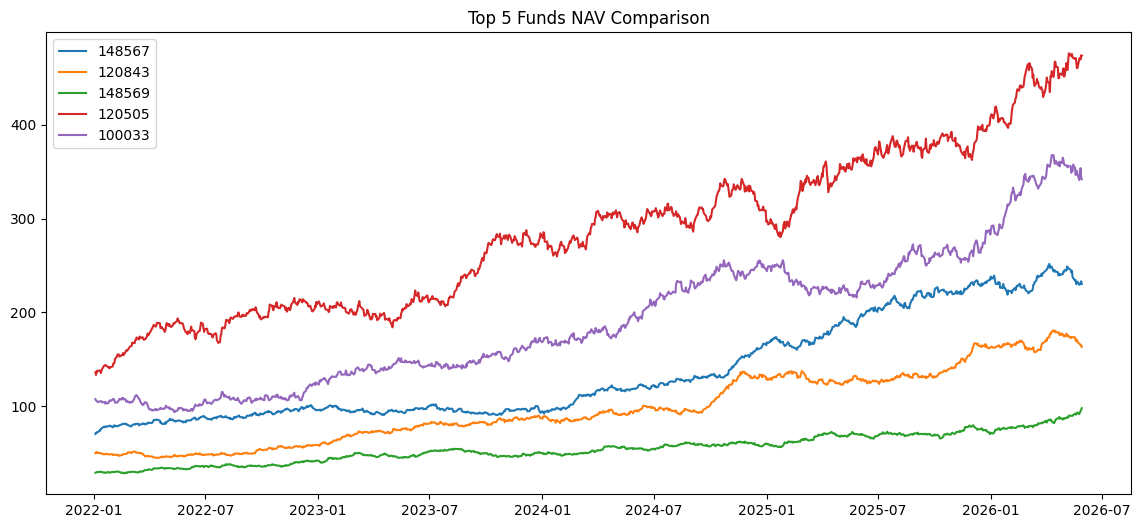

In [30]:
plt.figure(figsize=(14,6))

for code in top5:

    temp = top_nav[
        top_nav['amfi_code']==code
    ]

    plt.plot(
        temp['date'],
        temp['nav'],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.savefig(
    "../charts/benchmark_comparison.png"
)

plt.show()

In [31]:
scorecard.head()
alpha_beta_df.head()
drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [32]:
drawdown_df.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


In [33]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [34]:
print(alpha_beta_df.shape)
alpha_beta_df.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [35]:
scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
34,148567,0.309499,364.969375,0.269838,0.023684,-0.112657,5.0,1.0,7.0,8.0,5.15
30,120843,0.308833,329.299480,0.273305,-0.022830,-0.129740,6.0,2.0,5.0,13.0,6.55
36,148569,0.319245,311.202366,0.282704,0.018134,-0.163967,4.0,3.0,4.0,21.0,8.00
25,120505,0.328016,297.385502,0.292636,0.000549,-0.181885,1.0,5.0,3.0,25.0,8.40
2,100033,0.300997,275.612083,0.271954,0.005104,-0.162172,7.0,7.0,6.0,20.0,10.05
19,119551,0.257849,304.483175,0.232010,-0.031751,-0.150124,10.0,4.0,10.0,17.0,10.25
3,101206,0.235205,258.857759,0.213998,0.021086,-0.112916,12.0,9.0,12.0,9.0,10.50
38,149323,0.295581,285.294707,0.265986,-0.002523,-0.172481,8.0,6.0,8.0,22.0,11.00
24,120504,0.232774,258.684120,0.211948,0.016232,-0.125883,13.0,10.0,13.0,12.0,12.00
9,118632,0.240312,272.578113,0.218294,-0.008354,-0.174141,11.0,8.0,11.0,23.0,13.25


In [36]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [37]:
import os

print(os.listdir("../outputs"))

['alpha_beta.csv', 'cagr_table.csv', 'daily_returns.csv', 'fund_scorecard.csv', 'max_drawdown.csv', 'sharpe_ratio.csv', 'sortino_ratio.csv']


In [38]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,drawdown_rank,fund_score
34,148567,0.309499,364.969375,0.269838,0.023684,-0.112657,5.0,1.0,7.0,8.0,5.15
30,120843,0.308833,329.299480,0.273305,-0.022830,-0.129740,6.0,2.0,5.0,13.0,6.55
36,148569,0.319245,311.202366,0.282704,0.018134,-0.163967,4.0,3.0,4.0,21.0,8.00
25,120505,0.328016,297.385502,0.292636,0.000549,-0.181885,1.0,5.0,3.0,25.0,8.40
2,100033,0.300997,275.612083,0.271954,0.005104,-0.162172,7.0,7.0,6.0,20.0,10.05


In [39]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [41]:
scorecard.to_csv("../outputs/fund_scorecard.csv", index=False)

alpha_beta_df.to_csv("../outputs/alpha_beta.csv", index=False)

drawdown_df.to_csv("../outputs/max_drawdown.csv", index=False)
